In [1]:
from google.colab import files

In [3]:
f = files.upload()

Saving Untitled form (Responses).xlsx to Untitled form (Responses) (1).xlsx


In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_excel("Untitled form (Responses).xlsx")

In [6]:
df.head()

,Timestamp,What is your age group?,What is your current education level?,Which stream/field are you currently studying?,Which subject do you perform best in?,Which skills do you strongly possess?,"Rate your problem-solving ability\n(1 = Very Low, 5 = Very High)",Which area interests you the most?,"How much do your interests influence your career choice? (1 = Not at all, 5 = Very strongly)",How would you describe yourself?,Do you prefer working:,What influences your career decision the most?,Which career path are you most likely to choose?
0,2026-04-07 11:40:26.685,18–21,Undergraduate,Other,Arts/Creative Subjects,Creativity,3,"Creative Fields (Design, Media)",4,Ambivert,Individually,Personal Interest,Creative/Media
1,2026-04-07 12:36:12.447,18–21,Undergraduate,Commerce,Business/Management,Technical/IT Skills,3,Business/Management,2,Extrovert,Individually,Peer Influence,Business/Management
2,2026-04-07 17:12:18.239,Below 18,School Student,Commerce,Business/Management,Leadership,4,Healthcare,3,Ambivert,In a Team,Salary/Job Security,Government Sector
3,2026-04-07 17:12:57.594,18–21,Undergraduate,Arts/Humanities,Science,Analytical/Problem-Solving,5,Government Jobs,4,Extrovert,In a Team,Market Trends,Creative/Media
4,2026-04-07 17:13:26.631,22–25,Postgraduate,Arts/Humanities,Arts/Creative Subjects,Analytical/Problem-Solving,3,"Creative Fields (Design, Media)",5,Ambivert,In a Team,Peer Influence,Healthcare


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [8]:
# Cleaning column names for easier access
df.columns = [col.strip() for col in df.columns]

In [9]:
# --- 2. Exploratory Data Analysis (EDA) ---
print("### Dataset Overview ###")
print(df.info())

### Dataset Overview ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                                                                                        Non-Null Count  Dtype         
---  ------                                                                                        --------------  -----         
 0   Timestamp                                                                                     30 non-null     datetime64[ns]
 1   What is your age group?                                                                       30 non-null     object        
 2   What is your current education level?                                                         30 non-null     object        
 3   Which stream/field are you currently studying?                                                30 non-null     object        
 4   Which subject do you perform best in?                                                  

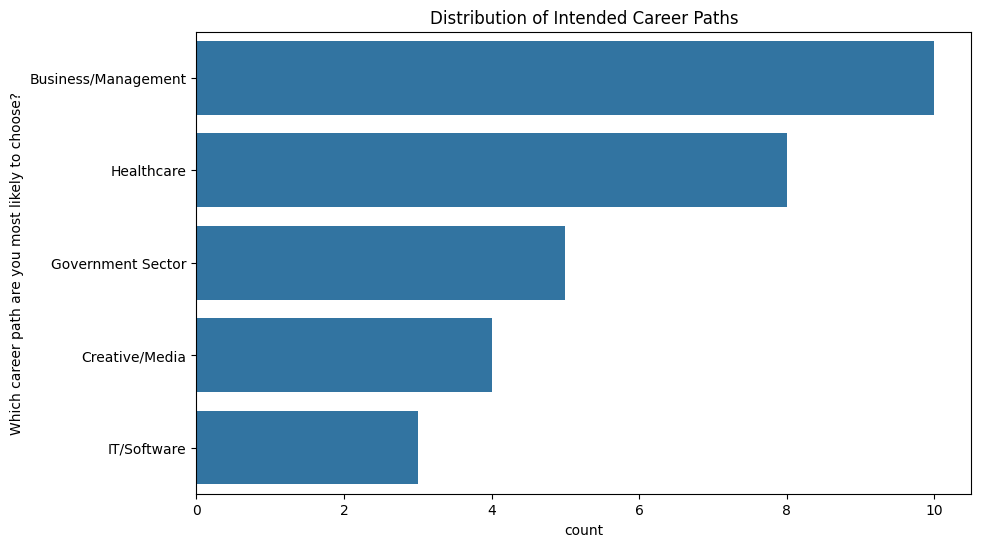

In [10]:
# Visualizing the Target Variable: Career Path
plt.figure(figsize=(10, 6))
sns.countplot(y='Which career path are you most likely to choose?', data=df, order=df['Which career path are you most likely to choose?'].value_counts().index)
plt.title('Distribution of Intended Career Paths')
plt.show()

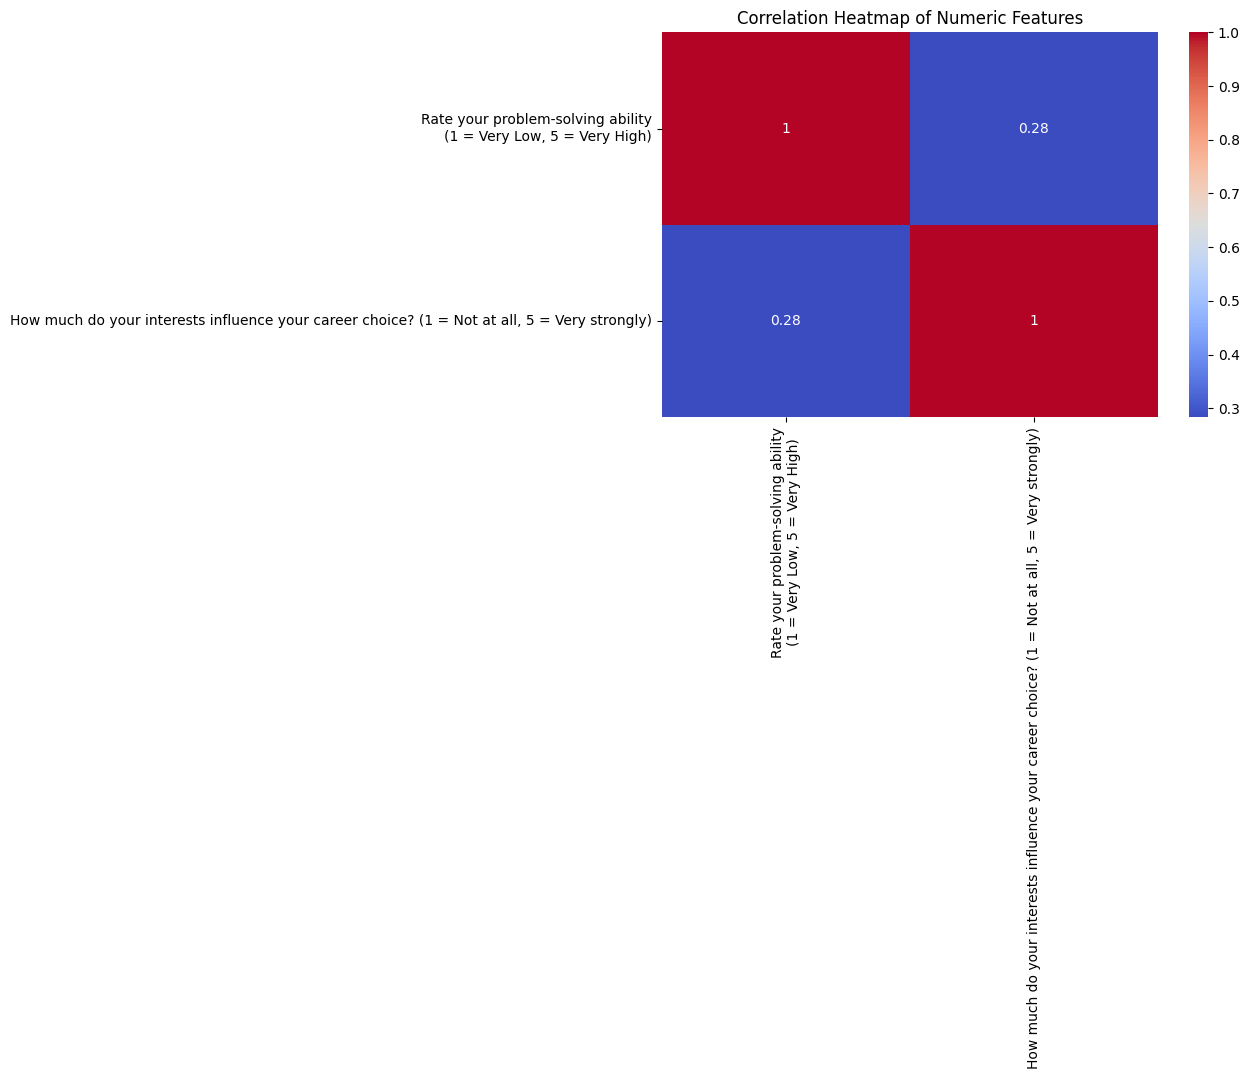

In [11]:
# Correlation Heatmap (Numeric only)
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [12]:
# --- 3. Data Preprocessing ---
# Drop Timestamp as it's not a predictor
df_ml = df.drop(columns=['Timestamp'])

In [13]:
# Encoding categorical variables
le_dict = {}
for column in df_ml.columns:
    if df_ml[column].dtype == 'object':
        le = LabelEncoder()
        df_ml[column] = le.fit_transform(df_ml[column])
        le_dict[column] = le  # Storing encoders to reverse mapping later if needed

In [15]:
# Splitting Features (X) and Target (y)
target_col = 'Which career path are you most likely to choose?'
X = df_ml.drop(columns=[target_col])
y = df_ml[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# --- 4. Machine Learning Model ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
# Predictions
y_pred = model.predict(X_test)

In [18]:
# --- 5. Evaluation ---
print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_dict[target_col].classes_))


Model Accuracy: 33.33%

Classification Report:
                     precision    recall  f1-score   support

Business/Management       0.33      0.50      0.40         2
     Creative/Media       0.00      0.00      0.00         1
  Government Sector       0.00      0.00      0.00         1
         Healthcare       0.50      1.00      0.67         1
        IT/Software       0.00      0.00      0.00         1

           accuracy                           0.33         6
          macro avg       0.17      0.30      0.21         6
       weighted avg       0.19      0.33      0.24         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


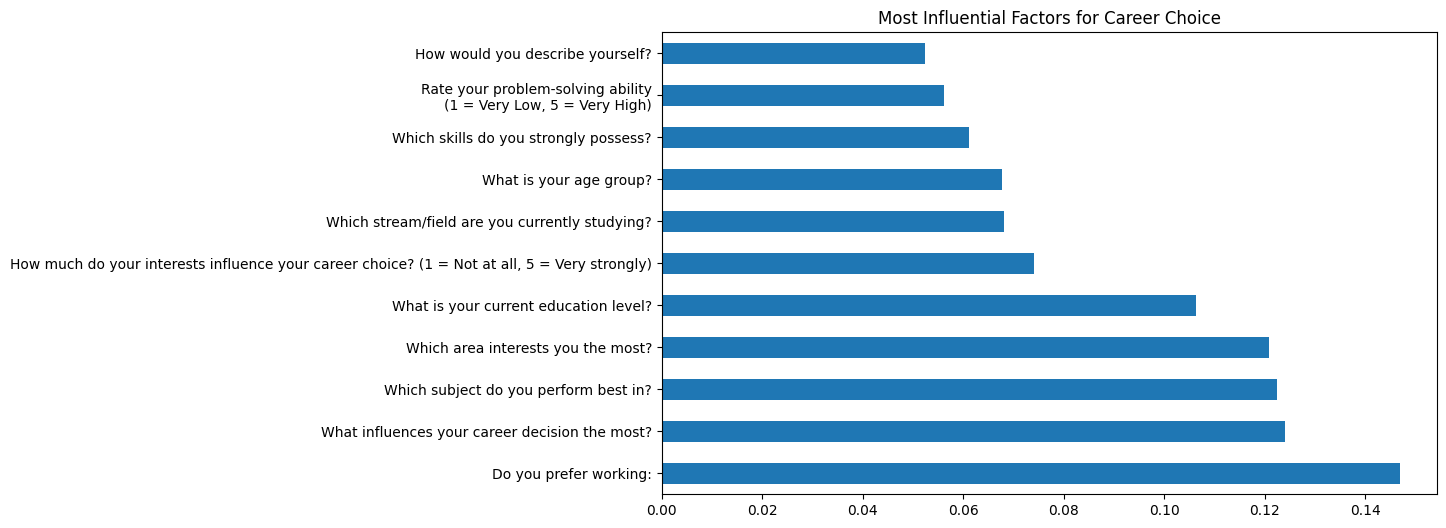

In [19]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.title('Most Influential Factors for Career Choice')
plt.show()